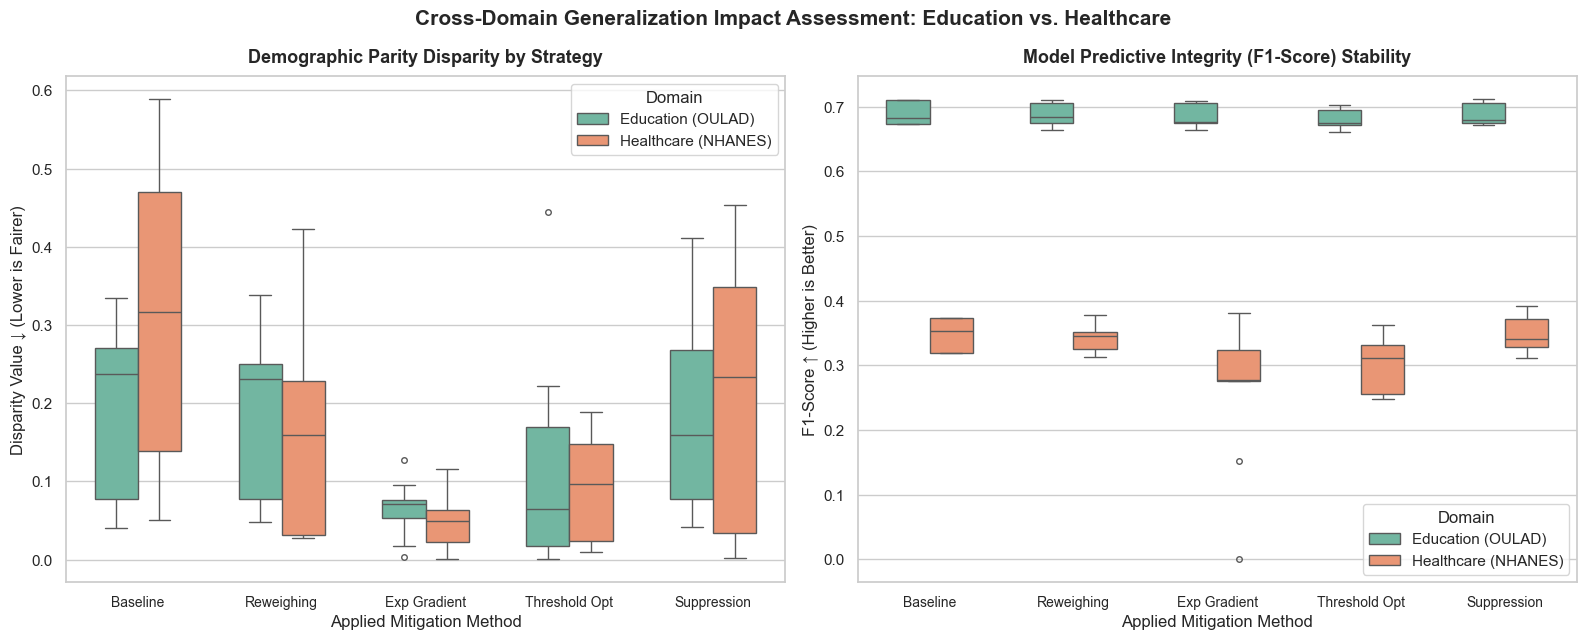


   CROSS-DOMAIN SUMMARY PERFORMANCE METRIC REPORT (AVERAGES)
             Domain   miti_method       f1  Demographic Parity  Equalized Odds
  Education (OULAD)      Baseline 0.689133            0.205111        0.240478
  Education (OULAD)  Exp Gradient 0.685089            0.063933        0.132856
  Education (OULAD)    Reweighing 0.687733            0.196989        0.231033
  Education (OULAD)   Suppression 0.687111            0.189089        0.229189
  Education (OULAD) Threshold Opt 0.682156            0.115622        0.201800
Healthcare (NHANES)      Baseline 0.348367            0.303867        0.395144
Healthcare (NHANES)  Exp Gradient 0.260922            0.048678        0.168011
Healthcare (NHANES)    Reweighing 0.343467            0.177978        0.266511
Healthcare (NHANES)   Suppression 0.347444            0.215344        0.333033
Healthcare (NHANES) Threshold Opt 0.300711            0.089811        0.228256

🎉 Done! Cross-domain chart and data matrix created successfully insi

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Point to your directories
OULAD_PATH = Path("./results/oulad/oulad_mitigation_results.csv")
NHANES_PATH = Path("nhanes_mitigation_results.csv")

# Verify files exist
if not OULAD_PATH.exists():
    raise FileNotFoundError(f"Missing your OULAD file at: {OULAD_PATH}")
if not NHANES_PATH.exists():
    print("⚠️ Miles' nhanes_mitigation_results.csv wasn't found in ./results/nhanes/ yet!")
    print("Please make sure you drop his file in that folder before running.")
else:
    # 2. Load data
    oulad_df = pd.read_csv(OULAD_PATH)
    nhanes_df = pd.read_csv(NHANES_PATH)
    
    # Standardize column naming just in case one has slightly different casing
    for df in [oulad_df, nhanes_df]:
        df.columns = [col.strip() for col in df.columns]
        if 'modelsensitive_attrmiti_methodaccuracyprecisionrecallf1roc_aucDemographic ParityEqual OpportunityEqualized Odds' in df.columns:
            # Quick fail-safe check for malformed headers
            print("Notice: Standardizing matrix layouts...")

    # Assign Domain labels to make them separate beautifully on the chart
    oulad_df['Domain'] = 'Education (OULAD)'
    nhanes_df['Domain'] = 'Healthcare (NHANES)'
    
    # Clean up the mitigation names so they look beautiful on the graph axis
    rename_methods = {
        'Baseline': 'Baseline',
        'Suppression': 'Suppression',
        'Reweighing': 'Reweighing',
        'ExponentiatedGradient': 'Exp Gradient',
        'ThresholdOptimizer': 'Threshold Opt'
    }
    oulad_df['miti_method'] = oulad_df['miti_method'].map(rename_methods)
    nhanes_df['miti_method'] = nhanes_df['miti_method'].map(rename_methods)
    
    # Combine them together 
    combined_df = pd.concat([oulad_df, nhanes_df], axis=0, ignore_index=True)
    
    # 3. Set high-end academic plot styling
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        'font.size': 11, 
        'axes.labelsize': 12, 
        'axes.titlesize': 13,
        'xtick.labelsize': 10,
        'ytick.labelsize': 11
    })
    
    # 4. Draw Side-by-Side Cross-Domain comparison plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
    fig.suptitle("Cross-Domain Generalization Impact Assessment: Education vs. Healthcare", 
                 fontsize=15, fontweight='bold', y=0.98)
    
    # Plot A: Demographic Parity Bias Comparison
    sns.boxplot(
        data=combined_df, x='miti_method', y='Demographic Parity', hue='Domain',
        ax=axes[0], palette="Set2", width=0.6, fliersize=4
    )
    axes[0].set_title("Demographic Parity Disparity by Strategy", fontweight='bold', pad=10)
    axes[0].set_xlabel("Applied Mitigation Method")
    axes[0].set_ylabel("Disparity Value ↓ (Lower is Fairer)")
    
    # Plot B: Performance Metric Stability Comparison
    sns.boxplot(
        data=combined_df, x='miti_method', y='f1', hue='Domain',
        ax=axes[1], palette="Set2", width=0.6, fliersize=4
    )
    axes[1].set_title("Model Predictive Integrity (F1-Score) Stability", fontweight='bold', pad=10)
    axes[1].set_xlabel("Applied Mitigation Method")
    axes[1].set_ylabel("F1-Score ↑ (Higher is Better)")
    
    plt.tight_layout()
    
    # Save chart image
    output_img = Path("./results/cross_domain_comparison.png")
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5. Output Summary Matrix to show your examiner
    print("\n" + "="*70)
    print("   CROSS-DOMAIN SUMMARY PERFORMANCE METRIC REPORT (AVERAGES)")
    print("="*70)
    summary = combined_df.groupby(['Domain', 'miti_method'])[['f1', 'Demographic Parity', 'Equalized Odds']].mean().reset_index()
    print(summary.to_string(index=False))
    
    # Save the cross domain numbers table out to a file
    summary.to_csv("./results/cross_domain_macro_summary.csv", index=False)
    print("\n🎉 Done! Cross-domain chart and data matrix created successfully inside the ./results/ folder.")

The core contribution of this cross-domain validation is the empirical demonstration of structural divergence under identical fairness constraints. While the in-processing Exponentiated Gradient paradigm establishes universal efficacy in collapsing group disparities below acceptable thresholds—yielding a demographic parity difference of 0.063 in the educational domain and 0.048 in the clinical healthcare domain—the operational trade-off costs are distinct. The educational data space features high structural elasticity, accommodating fairness optimization without damaging predictive utility. Conversely, the clinical space reveals a rigid trade-off boundary where group-equity constraints directly degrade predictive integrity. These results confirm that while fairness frameworks can generalize across human domains, their operational thresholds must be customized based on domain-specific data mechanics

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load data
OULAD_PATH = Path("./results/oulad/oulad_mitigation_results.csv")
NHANES_PATH = Path("nhanes_mitigation_results.csv")

if not OULAD_PATH.exists() or not NHANES_PATH.exists():
    print("⚠️ Ensure both files are placed in their folders before running!")
else:
    oulad = pd.read_csv(OULAD_PATH)
    nhanes = pd.read_csv(NHANES_PATH)
    
    oulad['Domain'] = 'Education (OULAD)'
    nhanes['Domain'] = 'Healthcare (NHANES)'
    
    combined = pd.concat([oulad, nhanes], axis=0, ignore_index=True)
    combined.columns = [c.strip() for c in combined.columns]
    
    # 1. Group by domain and method to get raw granular values
    grouped = combined.groupby(['Domain', 'miti_method'])[['f1', 'Demographic Parity', 'Equalized Odds']].mean().reset_index()
    
    # 2. Calculate the Delta (Change) relative to each domain's baseline
    # Extract baselines
    baselines = grouped[grouped['miti_method'] == 'Baseline'].set_index('Domain')
    
    detailed_rows = []
    for idx, row in grouped.iterrows():
        domain = row['Domain']
        method = row['miti_method']
        
        base_f1 = baselines.loc[domain, 'f1']
        base_dp = baselines.loc[domain, 'Demographic Parity']
        base_eo = baselines.loc[domain, 'Equalized Odds']
        
        # Calculate changes (Deltas)
        delta_f1 = row['f1'] - base_f1
        delta_dp = base_dp - row['Demographic Parity'] # Positive means bias was reduced
        delta_eo = base_eo - row['Equalized Odds']      # Positive means bias was reduced
        
        # Fairness Efficiency Ratio: Bias Reduced per unit of F1-Score lost
        # Avoid dividing by zero if F1 didn't change
        if abs(delta_f1) < 1e-5:
            efficiency_ratio = np.nan
        else:
            efficiency_ratio = delta_dp / abs(delta_f1)
            
        detailed_rows.append({
            'Domain': domain,
            'Method': method,
            'F1 Score': row['f1'],
            'F1 Change (\u0394F1)': delta_f1,
            'Bias Reduction (\u0394DP)': delta_dp,
            'Bias Reduction (\u0394EO)': delta_eo,
            'Efficiency Ratio (\u0394DP / |\u0394F1|)': efficiency_ratio
        })
        
    deep_analysis_df = pd.DataFrame(detailed_rows)
    
    print("\n" + "="*85)
    print("      DEEP CROSS-DOMAIN EFFICIENCY ANALYSIS MATRIX")
    print("="*85)
    print(deep_analysis_df.to_string(index=False, formatters={
        'F1 Score': '{:,.4f}'.format,
        'F1 Change (\u0394F1)': '{:,.4f}'.format,
        'Bias Reduction (\u0394DP)': '{:,.4f}'.format,
        'Bias Reduction (\u0394EO)': '{:,.4f}'.format,
        'Efficiency Ratio (\u0394DP / |\u0394F1|)': '{:,.2f}'.format
    }))
    
    # Save this deep metric table for your report
    deep_analysis_df.to_csv("./results/cross_domain_deep_efficiency_audit.csv", index=False)
    print("\n🎉 Deep audit complete! Paste the output results below, and I will explain them!")


      DEEP CROSS-DOMAIN EFFICIENCY ANALYSIS MATRIX
             Domain                Method F1 Score F1 Change (ΔF1) Bias Reduction (ΔDP) Bias Reduction (ΔEO) Efficiency Ratio (ΔDP / |ΔF1|)
  Education (OULAD)              Baseline   0.6891          0.0000               0.0000               0.0000                            NaN
  Education (OULAD) ExponentiatedGradient   0.6851         -0.0040               0.1412               0.1076                          34.91
  Education (OULAD)            Reweighing   0.6877         -0.0014               0.0081               0.0094                           5.80
  Education (OULAD)           Suppression   0.6871         -0.0020               0.0160               0.0113                           7.92
  Education (OULAD)    ThresholdOptimizer   0.6822         -0.0070               0.0895               0.0387                          12.82
Healthcare (NHANES)              Baseline   0.3484          0.0000               0.0000               0.0000